In [22]:
# ===============================
# 1. Import Libraries
# ===============================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score,
    roc_curve, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor

import joblib
import warnings
warnings.filterwarnings('ignore')

In [23]:
# ===============================
# 2. Load Dataset
# ===============================

df = pd.read_csv('diabetes.csv')

print('Dataset Shape:', df.shape)
print(df.head())

Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

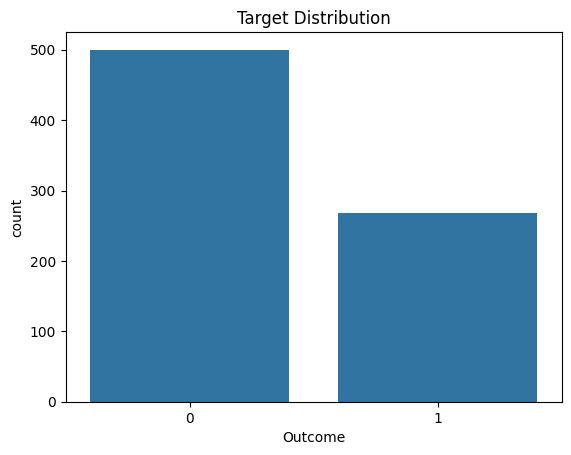

In [24]:
# ===============================
# 3. Basic EDA
# ===============================

print(df.info())
print(df.describe())

print(df['Outcome'].value_counts())

sns.countplot(x='Outcome', data=df)
plt.title('Target Distribution')
plt.show()

In [25]:
# ===============================
# 4. Replace Impossible Zeros with NaN
# ===============================

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [26]:
# ===============================
# 5. Fill Missing Values (Median by Outcome)
# ===============================

for column in cols:
    df[column] = df.groupby('Outcome')[column] \
                   .transform(lambda x: x.fillna(x.median()))

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


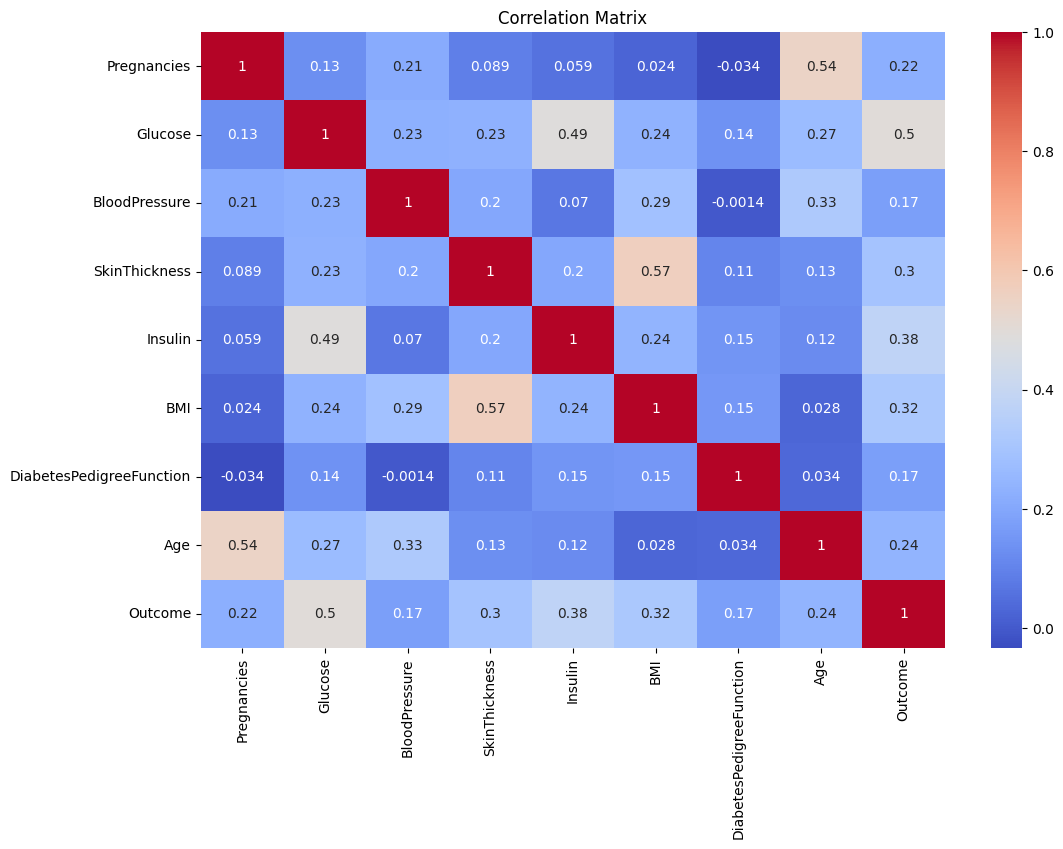

In [27]:
# ===============================
# 6. Correlation Analysis
# ===============================

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [28]:
# ===============================
# 7. Outlier Detection (LOF)
# ===============================

lof = LocalOutlierFactor(n_neighbors=20)
lof.fit_predict(df.drop('Outcome', axis=1))

outlier_scores = lof.negative_outlier_factor_
threshold = np.sort(outlier_scores)[10]

outliers = outlier_scores < threshold
df = df[~outliers]

print('Dataset after removing outliers:', df.shape)

Dataset after removing outliers: (758, 9)


In [29]:
# ===============================
# 8. Feature Engineering
# ===============================

df['BMI_CAT'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 34.9, 39.9, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obesity1', 'Obesity2', 'Obesity3']
)

df['GLUCOSE_CAT'] = pd.cut(
    df['Glucose'],
    bins=[0, 70, 99, 126, 300],
    labels=['Low', 'Normal', 'Prediabetes', 'Diabetes']
)

df['INSULIN_CAT'] = np.where(
    (df['Insulin'] >= 16) & (df['Insulin'] <= 166),
    'Normal', 'Abnormal'
)

In [30]:
# ===============================
# 9. One Hot Encoding
# ===============================

df = pd.get_dummies(df, drop_first=True)

In [31]:
# ===============================
# 10. Feature / Target Split
# ===============================

y = df['Outcome']
X = df.drop('Outcome', axis=1)

feature_names = X.columns.tolist()  # save before scaling

In [32]:
# ===============================
# 11. Feature Scaling
# ===============================

scaler = RobustScaler()
X = scaler.fit_transform(X)

In [33]:
# ===============================
# 12. Train Test Split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
# ===============================
# 13. Model Comparison (10-Fold CV)
# ===============================

base_models = [
    ('Logistic Regression', LogisticRegression()),
    ('Decision Tree',       DecisionTreeClassifier()),
    ('Random Forest',       RandomForestClassifier()),
    ('Gradient Boosting',   GradientBoostingClassifier())
]

print('Model Performance (10-Fold CV Accuracy):')
for name, model in base_models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    print(f'  {name}: {cv_results.mean():.4f} (+/- {cv_results.std():.4f})')

Model Performance (10-Fold CV Accuracy):
  Logistic Regression: 0.8367 (+/- 0.0504)
  Decision Tree: 0.8317 (+/- 0.0547)
  Random Forest: 0.8779 (+/- 0.0314)
  Gradient Boosting: 0.8813 (+/- 0.0324)


In [35]:
# ===============================
# 14. Random Forest Tuning (GridSearchCV)
# ===============================

rf_params = {
    'n_estimators':      [200, 500],
    'max_depth':         [5, 8, None],
    'min_samples_split': [2, 5],
    'max_features':      [3, 5, 7]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                       cv=10, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print('Best RF Params:', rf_grid.best_params_)
rf_final = rf_grid.best_estimator_

Fitting 10 folds for each of 36 candidates, totalling 360 fits
Best RF Params: {'max_depth': 8, 'max_features': 7, 'min_samples_split': 5, 'n_estimators': 200}


In [36]:
# ===============================
# 15. Gradient Boosting Tuning (GridSearchCV)
# ===============================

gb_params = {
    'learning_rate': [0.01, 0.1],
    'n_estimators':  [100, 500],
    'max_depth':     [3, 5]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(), gb_params,
                       cv=10, n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print('Best GB Params:', gb_grid.best_params_)
gb_final = gb_grid.best_estimator_

Fitting 10 folds for each of 8 candidates, totalling 80 fits
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [37]:
# ===============================
# 16. Final Model Evaluation — All Algorithms
# ===============================

# Collect all final (fitted) models
lr_final = LogisticRegression()
lr_final.fit(X_train, y_train)

dt_final = DecisionTreeClassifier()
dt_final.fit(X_train, y_train)

final_models = [
    ('Logistic Regression', lr_final),
    ('Decision Tree',       dt_final),
    ('Random Forest',       rf_final),
    ('Gradient Boosting',   gb_final)
]

# ── Accuracy Summary Table ──────────────────────────────────────────────────
print('=' * 55)
print(f'{"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10}')
print('=' * 55)

for name, model in final_models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    print(f'{name:<25} {acc:>10.4f} {auc:>10.4f}')

print('=' * 55)

Model                       Accuracy    ROC-AUC
Logistic Regression           0.9013     0.9441
Decision Tree                 0.8158     0.7981
Random Forest                 0.9079     0.9698
Gradient Boosting             0.9079     0.9696


In [38]:
# ── Classification Reports ──────────────────────────────────────────────────
for name, model in final_models:
    y_pred = model.predict(X_test)
    print(f'\n{"─" * 50}')
    print(f'  Classification Report — {name}')
    print(f'{"─" * 50}')
    print(classification_report(y_test, y_pred))


──────────────────────────────────────────────────
  Classification Report — Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       104
           1       0.84      0.85      0.85        48

    accuracy                           0.90       152
   macro avg       0.88      0.89      0.89       152
weighted avg       0.90      0.90      0.90       152


──────────────────────────────────────────────────
  Classification Report — Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       104
           1       0.69      0.75      0.72        48

    accuracy                           0.82       152
   macro avg       0.79      0.80      0.79       152
weighted avg       0.82      0.82      0.82       152


──────────────────────────────────────────────────
  

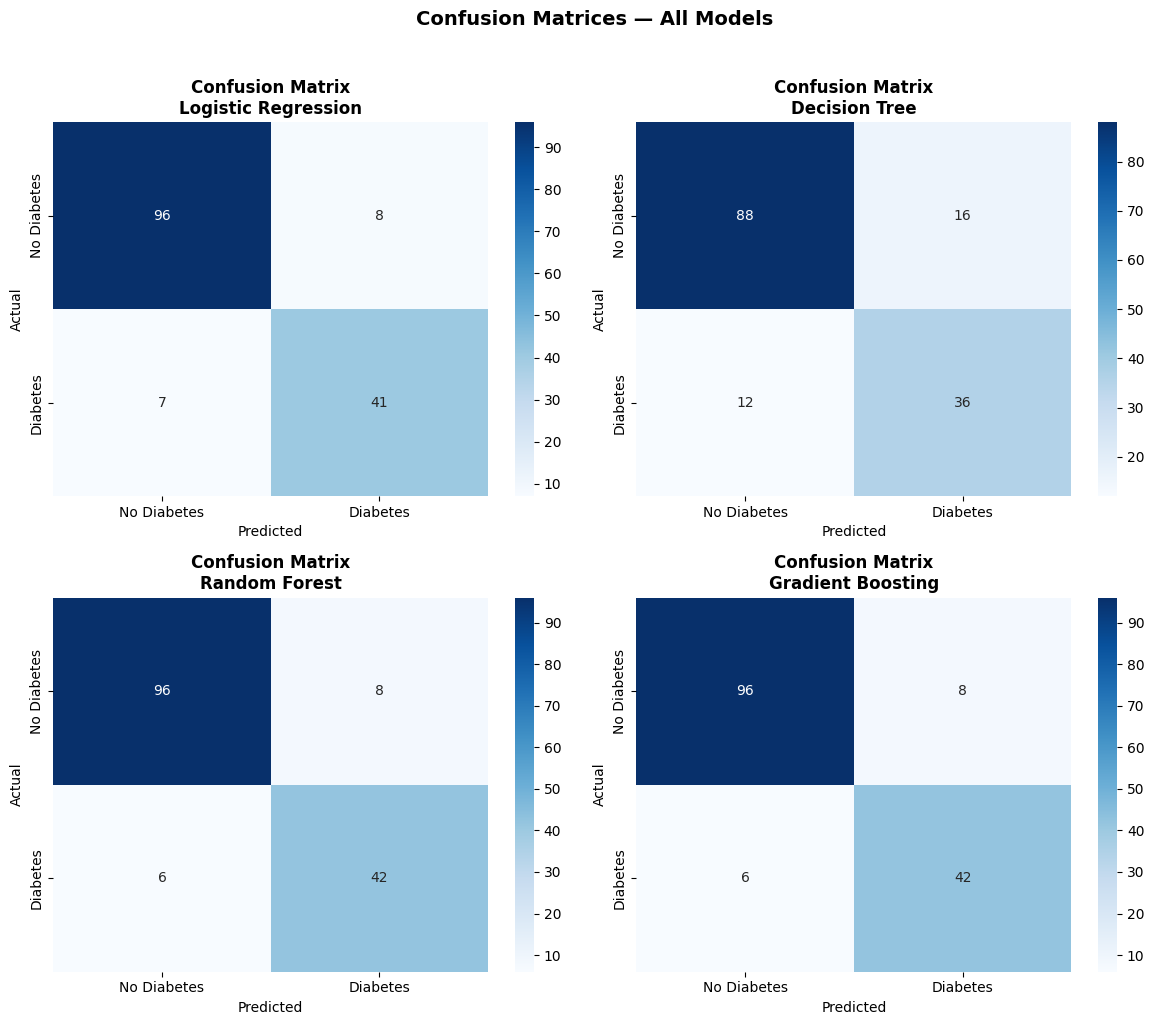

In [39]:
# ── Confusion Matrices (2 × 2 Grid) ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(final_models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Diabetes', 'Diabetes'],
        yticklabels=['No Diabetes', 'Diabetes'],
        ax=axes[i]
    )
    axes[i].set_title(f'Confusion Matrix\n{name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

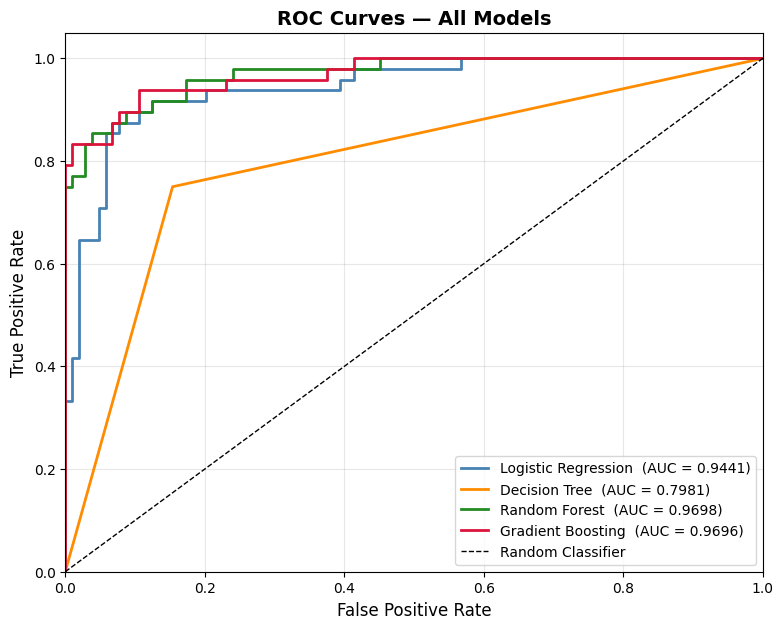

In [40]:
# ── ROC Curves (All Models on One Plot) ─────────────────────────────────────
colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']

plt.figure(figsize=(9, 7))

for (name, model), color in zip(final_models, colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

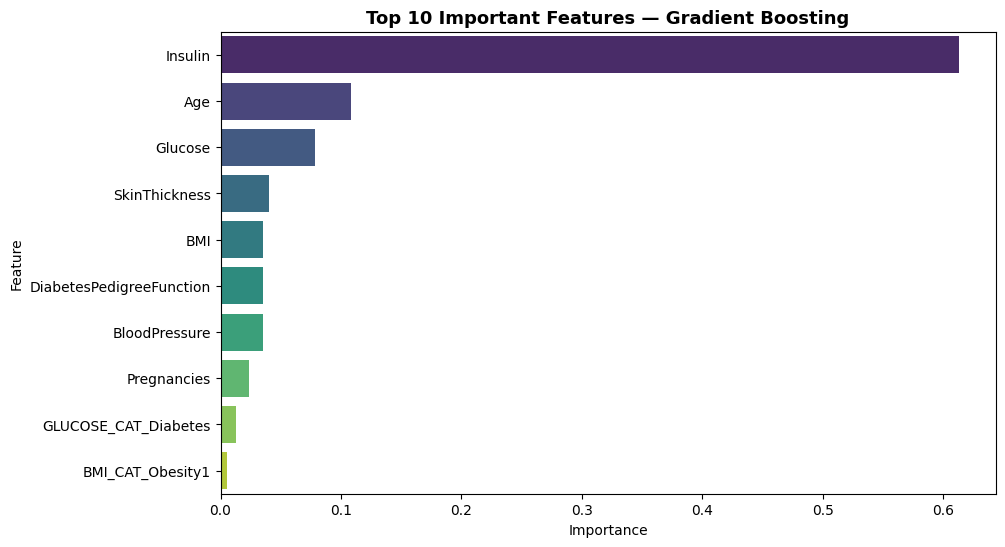

In [41]:
# ===============================
# 17. Feature Importance (Gradient Boosting)
# ===============================

importances = gb_final.feature_importances_

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Important Features — Gradient Boosting', fontsize=13, fontweight='bold')
plt.show()

In [42]:
# ===============================
# 18. Save Best Model
# ===============================

joblib.dump(gb_final, 'diabetes_model.pkl')
print('Model Saved Successfully as diabetes_model.pkl!')

Model Saved Successfully as diabetes_model.pkl!
